<a href="https://colab.research.google.com/github/cl0udy322322-crypto/project2/blob/main/DIYDAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
pip install -U finance-datareader

In [26]:
# mq_quant.py

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'}

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()


def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """

    # 1. 리밸런싱 날짜 구하기 (전체 데이터 기준)
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 날짜 동기화 (weight_df가 있다면, 교집합 날짜만 사용)
    # close_data가 더 길어도, weight_df가 있는 기간만 백테스팅 수행
    if weight_df is not None:
        # weight_df 인덱스에 포함된 날짜만 필터링
        rebal_dates = rebal_dates[rebal_dates.isin(weight_df.index)]

        # 만약 겹치는 날짜가 하나도 없다면 에러 처리
        if rebal_dates.empty:
            print("Error: close_data와 weight_df의 리밸런싱 날짜가 일치하지 않습니다.")
            return None, None

    # 3. 초기 비중 설정 (없으면 동일 비중)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 4. 데이터 범위 보정 (시작일 기준)
    first_date = rebal_dates[0] # 필터링된 첫 날짜


    # 전체 기간 수익률 계산
    full_daily_rets = close_data.pct_change().fillna(0)

    # 백테스트 시작일 이후 데이터만 슬라이싱
    daily_rets = full_daily_rets.loc[first_date:]

    portfolio_chunks = []
    total_value = 1.0

    # 리밸런싱 기간별 순회
    full_dates = list(rebal_dates)

    # 마지막 구간 처리: 마지막 리밸런싱 날짜 ~ 데이터 끝 날짜
    # (단, daily_rets의 마지막 날짜가 리밸런싱 날짜보다 뒤에 있을 때만)
    if full_dates[-1] < daily_rets.index[-1]:
        full_dates.append(daily_rets.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        # start가 weight_df에 없으면 건너뜀 (안전 장치)
        if start not in weight_df.index:
            continue

        current_weights = weight_df.loc[start]

        # start 다음날부터 end까지의 수익률 사용 (start 당일은 리밸런싱 날)
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue

        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0 # 시작점 1.0 강제 할당
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
        historical_max = portfolio_cum_ret.cummax()
        dd = (portfolio_cum_ret - historical_max) / historical_max * 100
        mdd = dd.min()

        # [수정] 전체 컬럼이 아니라, weight_df에 존재하는(실제 투자된) 티커만 추출
        if weight_df is not None:
            # weight_df의 컬럼 중 close_data에도 존재하는 것만 리스트로 만듦 (KeyError 방지)
            tickers = [col for col in weight_df.columns if col in close_data.columns]

            if 'cash' in tickers: tickers.remove('cash')
        else:
            tickers = close_data.columns.tolist()

        plot_daily_rets = full_daily_rets.loc[portfolio_cum_ret.index]

        plot_portfolio_result(tickers, plot_daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret


def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수 (백테스트 기간 일치 버전)
    """

    plt.figure(figsize=(10, 8))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 2. 개별 종목 흐름 그리기 (기간 매칭 및 리베이스)
    if daily_rets is not None and tickers is not None:

        # [핵심 수정] 포트폴리오의 시작/종료 날짜 구하기
        start_date = port_cum_ret.index[0]
        end_date = port_cum_ret.index[-1]

        # [핵심 수정] 전체 데이터(daily_rets)를 실제 백테스트 기간만큼만 자르기
        subset_daily_rets = daily_rets.loc[start_date:end_date]

        for t in tickers:
            if t in subset_daily_rets.columns:
                # [핵심 수정] 잘라낸 기간의 수익률로 누적 수익률 새로 계산
                # 이렇게 해야 시작점이 1.0(혹은 포트폴리오 시작점) 근처로 맞춰집니다.
                ind_cum = (1 + subset_daily_rets[t]).cumprod()

                # 시각화 (투명도 조절)
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    # Y축 로그 스케일 및 포맷 설정
    plt.yscale('log')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')

    # 범례가 너무 많으면 가리니까, 적절히 위치 조정
    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3)
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%')

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()

In [27]:
# DAA 함수
def get_daa_regime(close_data, canary_assets):
    """
    카나리아 자산을 분석하여 현재 시장의 투자 국면(Regime)을 진단합니다.
    리턴값:
        2: 공격 모드 (Full Attack - 팩터 투자 실행)
        1: 중립 모드 (Balanced - 팩터 50% + 수비 50%)
        0: 수비 모드 (Defensive - 안전자산 100%)
    """
    canary_data = close_data[canary_assets].copy()

    rebal_dates = get_rebalancing_dates(canary_data)
    v_data = canary_data.loc[rebal_dates]

    m1 = v_data.pct_change(1)
    m3 = v_data.pct_change(3)
    m6 = v_data.pct_change(6)
    m12 = v_data.pct_change(12)

    momentum_score = (12 * m1) + (4 * m3) + (2 * m6) + m12
    momentum_score.dropna(inplace=True)

    regime_series = (momentum_score > 0).sum(axis=1)

    return regime_series

# 공격자산 함수
def execute_aggressive(daaAttack):
    return pd.Series([1.0], index=daaAttack)

# 수비자산 함수
def execute_defensive(daaDefense):
    unit_weight = 1.0 / len(daaDefense)
    return pd.Series(unit_weight, index=daaDefense)

In [28]:
# main.py
import yfinance as yf
import pandas as pd

daaAttack = ["000660.KS"]
daaDefense = ['SHY', 'GLD', 'DIA', 'LQD', 'HYG']
daaCol = ["000660.KS", 'SHY', 'GLD', 'DIA', 'LQD', 'HYG']
daaCanary = ['SPY', 'LQD']

all_tickers = list(set(daaCol + daaCanary))
start_date = '2015-01-01'
end_date = '2026-01-14'
print(f"Downloading data for: {all_tickers}")

raw_data = yf.download(all_tickers, start=start_date, end=end_date)
try:
    close_data = raw_data['Adj Close'].copy()
except KeyError:
    close_data = raw_data['Close'].copy()
close_data = close_data.ffill().dropna()

regime_series = get_daa_regime(close_data, daaCanary)
all_rebal_weights = []

for date, mode in regime_series.items():
    current_date_weight = pd.Series(dtype=float)

    # [Case 2]: 공격 모드
    if mode == 2:
        # 공격 100%
        attack_weight = execute_aggressive(daaAttack)
        current_date_weight = attack_weight * 1.0

    # [Case 1] 중립 모드
    elif mode == 1:
        # 공격 50% + 수비 50%
        attack_weight = execute_aggressive(daaAttack)
        defense_weight = execute_defensive(daaDefense)

        current_date_weight = (attack_weight * 0.5).add(defense_weight * 0.5, fill_value=0)

    # [Case 0] 수비 모드
    else:
        # 수비 100%
        defense_weight = execute_defensive(daaDefense)
        current_date_weight = defense_weight * 1.0

    current_date_weight.name = date
    all_rebal_weights.append(current_date_weight)

# 전체 비중 데이터프레임 생성
final_weight_df = pd.DataFrame(all_rebal_weights).fillna(0)

# 전략 실행하여 비중 산출
daaWeight = final_weight_df.copy()

# 사용자님이 요청하신 성과 지표 출력 구간
print("\n--- 전략 성과 평가 결과 ---")
daaDayReturn, daaCumReturn = cal_rebalancing_portfolio(
    close_data=close_data.loc[daaWeight.index[0]:],
    weight_df=daaWeight,
    enable_plot=False
)

daaCagr, daaDD, daaMDD = evaluate_performance(daaDayReturn, daaCumReturn)


[*********************100%***********************]  7 of 7 completed



--- 전략 성과 평가 결과 ---
▶ 최종 수익률   : 2242.00%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 36.02%
2. 안정성 (MDD)  : -36.60%
------------------------------
3. 연간 변동성   : 31.89%
4. 샤프 지수     : 1.0615


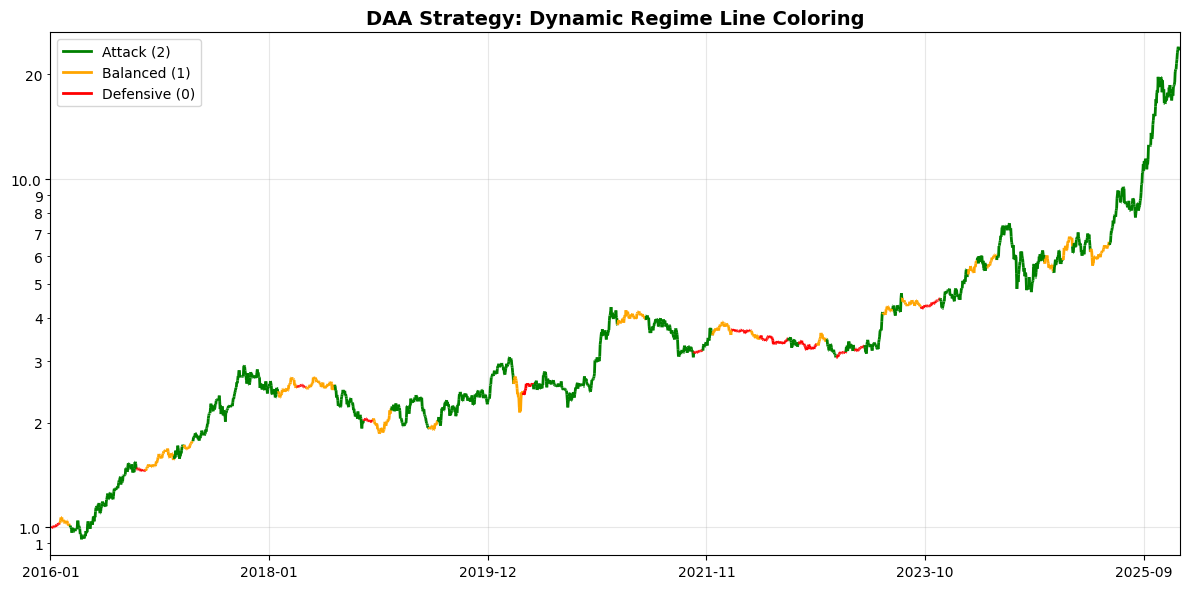

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

def plot_colored_line_strategy(cum_return, regime_series):
    """
    수익률 곡선의 선 색상을 국면(Regime)별로 다르게 표시합니다.
    - 2 (Attack): 초록색 (적극적 수익 추구)
    - 1 (Balanced): 주황색 (중립적 방어)
    - 0 (Defensive): 빨간색 (보수적 대피)
    """
    regime_daily = regime_series.reindex(cum_return.index).ffill()

    x = np.arange(len(cum_return))
    y = cum_return.values
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    colors = []
    for r in regime_daily.values[:-1]:
        if r == 2: colors.append('green')
        elif r == 1: colors.append('orange')
        else: colors.append('red')

    lc = LineCollection(segments, colors=colors, linewidths=2)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.add_collection(lc)


    ax.set_xlim(0, len(cum_return))
    ax.set_ylim(cum_return.min() * 0.9, cum_return.max() * 1.1)
    ax.set_yscale('log')

    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())

    def format_date(x, pos=None):
        if 0 <= x < len(cum_return):
            return cum_return.index[int(x)].strftime('%Y-%m')
        return ''
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_date))

    custom_lines = [Line2D([0], [0], color='green', lw=2),
                    Line2D([0], [0], color='orange', lw=2),
                    Line2D([0], [0], color='red', lw=2)]
    ax.legend(custom_lines, ['Attack (2)', 'Balanced (1)', 'Defensive (0)'], loc='upper left')

    plt.title('DAA Strategy: Dynamic Regime Line Coloring', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- 실행 부분 ---
plot_colored_line_strategy(daaCumReturn, regime_series.loc[daaWeight.index])